# 08 — Análise de erros por redshift e S/N (todos os modelos)

Onde cada modelo falha mais? Plots para o TCC (estilo SciencePlots):
1. σ_NMAD(z)  2. bias(z)  3. taxa de outliers(z) (η>0.15)  4. σ_NMAD vs S/N.
Lê `predictions.npz` de cada modelo. S/N vem do `catalog/sn_median` (só modelos com `test_idx`).

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, h5py
import scienceplots  # noqa: F401  (registra os estilos 'science', 'nature', 'ieee')

# Estilo de publicacao. 'no-latex' usa mathtext (robusto, sem depender de LaTeX/pacotes).
plt.style.use(['science', 'no-latex', 'grid'])
plt.rcParams.update({'figure.dpi': 120, 'legend.fontsize': 7, 'axes.titlesize': 10})

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from config import RESULTS_DIR
from src.evaluation.metrics import metrics_by_redshift_bin, sigma_nmad

OBJS   = ['LRG', 'ELG', 'QSO']
MODELS = ['xgboost_baseline', 'cnn_baseline', 'cnn_linedet']
LABEL  = {'xgboost_baseline': 'XGBoost', 'cnn_baseline': 'CNN baseline', 'cnn_linedet': 'CNN linedet'}
OUT_DIR = RESULTS_DIR / 'error_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_pred(obj, model):
    p = RESULTS_DIR / obj / model / 'predictions.npz'
    if not p.exists():
        return None
    d = np.load(p)
    out = {'y_test': d['y_test'], 'y_pred': d['y_pred'], 'delta_z': d['delta_z']}
    if 'test_idx' in d.files:
        out['test_idx'] = d['test_idx']
    return out

data = {(o, m): d for o in OBJS for m in MODELS if (d := load_pred(o, m)) is not None}
print('Carregados:', [f'{o}/{m}' for (o, m) in data])

def bins_df(obj, model, n_bins=10):
    d = data[(obj, model)]
    return pd.DataFrame(metrics_by_redshift_bin(d['y_test'], d['y_pred'], n_bins=n_bins)['bins'])

Carregados: ['LRG/xgboost_baseline', 'LRG/cnn_baseline', 'ELG/xgboost_baseline', 'ELG/cnn_baseline', 'ELG/cnn_linedet', 'QSO/xgboost_baseline']


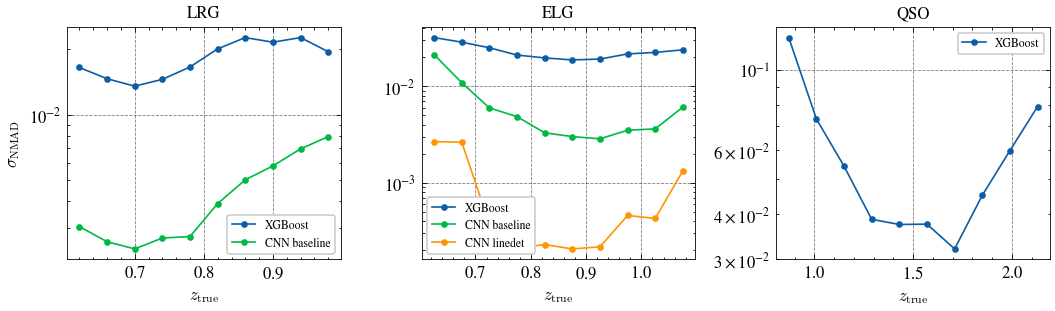

In [3]:
def plot_vs_z(key, ylabel, fname, logy=False, hline=None):
    fig, axes = plt.subplots(1, len(OBJS), figsize=(9, 2.8), squeeze=False, sharex=False)
    for j, obj in enumerate(OBJS):
        ax = axes[0, j]
        for m in MODELS:
            if (obj, m) in data:
                b = bins_df(obj, m)
                ax.plot(b['z_center'], b[key], marker='o', ms=3, label=LABEL[m])
        if hline is not None:
            ax.axhline(hline, color='k', ls='--', lw=0.8)
        if logy:
            ax.set_yscale('log')
        ax.set_title(obj); ax.set_xlabel(r'$z_{\mathrm{true}}$')
        if j == 0:
            ax.set_ylabel(ylabel)
        ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

# 1. sigma_NMAD(z)
plot_vs_z('nmad', r'$\sigma_{\mathrm{NMAD}}$', 'nmad_vs_z.png', logy=True)

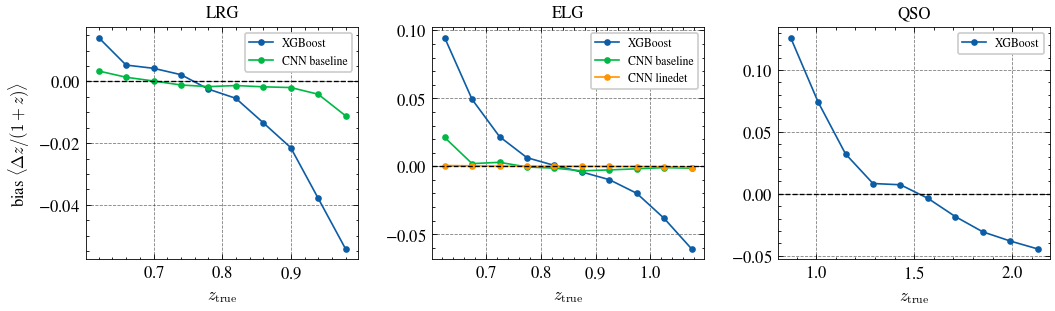

In [4]:
# 2. bias(z)  (mediana de Delta z/(1+z) por bin)
plot_vs_z('bias', r'bias $\langle \Delta z/(1+z) \rangle$', 'bias_vs_z.png', hline=0.0)

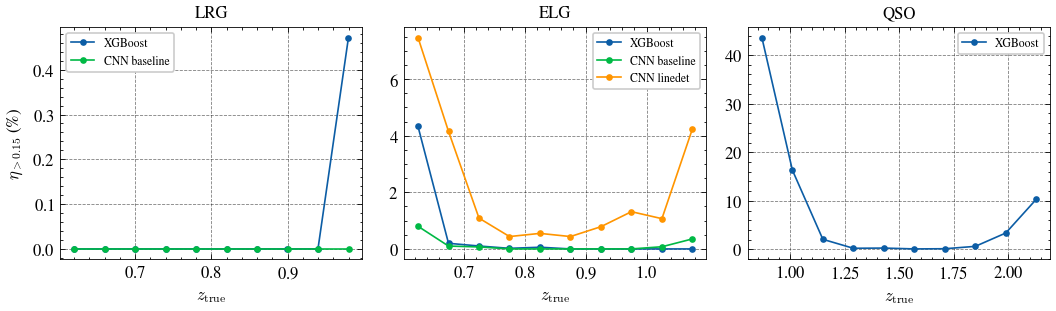

In [5]:
# 3. taxa de outliers(z)  (eta>0.15)
plot_vs_z('outliers_pct', r'$\eta_{>0.15}$ (\%)' if plt.rcParams['text.usetex'] else r'$\eta_{>0.15}$ (%)',
          'outliers_vs_z.png')

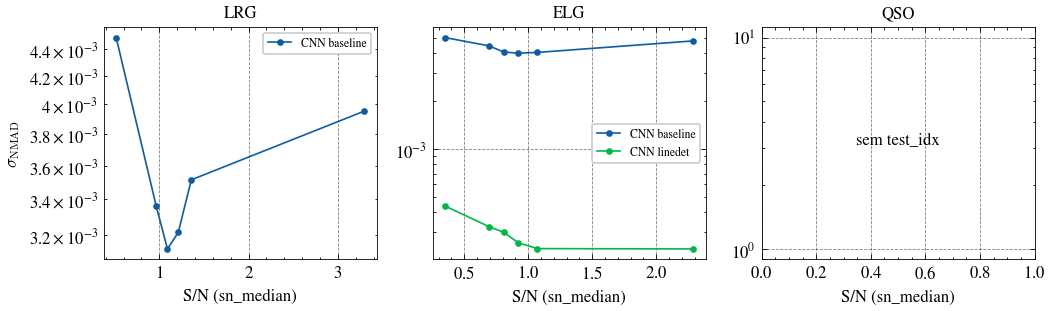

In [6]:
# 4. sigma_NMAD vs S/N  (so' modelos com test_idx -> mapeia sn_median do catalogo)
def sn_median(obj):
    with h5py.File(ROOT / f'data/processed/{obj}/{obj}spectra_padded.h5', 'r') as f:
        return f['catalog']['sn_median'][:]

fig, axes = plt.subplots(1, len(OBJS), figsize=(9, 2.8), squeeze=False)
for j, obj in enumerate(OBJS):
    ax = axes[0, j]
    sn_all = None
    for m in MODELS:
        d = data.get((obj, m))
        if d is None or 'test_idx' not in d:
            continue
        if sn_all is None:
            sn_all = sn_median(obj)
        sn = sn_all[d['test_idx']]
        edges = np.nanpercentile(sn, np.linspace(0, 100, 7))
        xc, yv = [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (sn >= lo) & (sn < hi)
            if mask.sum() > 30:
                xc.append(0.5 * (lo + hi)); yv.append(sigma_nmad(d['delta_z'][mask]))
        ax.plot(xc, yv, marker='o', ms=3, label=LABEL[m])
    ax.set_yscale('log'); ax.set_title(obj); ax.set_xlabel('S/N (sn\\_median)' if plt.rcParams['text.usetex'] else 'S/N (sn_median)')
    if j == 0:
        ax.set_ylabel(r'$\sigma_{\mathrm{NMAD}}$')
    if ax.has_data():
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'sem test_idx', ha='center', transform=ax.transAxes)
fig.tight_layout()
fig.savefig(OUT_DIR / 'nmad_vs_sn.png', dpi=300, bbox_inches='tight')
plt.show()

**Leitura:** σ_NMAD(z) mostra em que faixa de z cada modelo erra mais; bias(z) revela viés sistemático
dependente de z; outliers(z) localiza as catástrofes; σ_NMAD vs S/N mostra a degradação graciosa.
Figuras (300 dpi, estilo SciencePlots) em `results/error_analysis/`. (XGBoost não tem `test_idx` → fora do painel de S/N.)